# 模型预训练 随机距离1.5mm-3mm 

#### 使用v6模型,损失计算指标为振幅和相位

### 采用pinet_dataset_0408数据集 同0115 .npy数据 振幅相位用我们的方法 

#### review版本改了dataset和dataloader构造，现在训练更加具有随机性，减少过拟合

### 衍射图像赋予权重为1 

### 此脚本为通用模板 后续修改文件夹命名、模型命名、网络版本、Loss类别即可

## 导入库

In [1]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import torch.backends.cudnn as cudnn
import os
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from model import PINet_cpx_v6
from model import PINet_cpx_v6_pre
import torch.nn.functional as F
from mydataset import ComplexDataset_npy_plus,make_collate_fn
from myloss import ComplexLoss_amp_phs
from utilities import *


## 参数及路径设置

In [2]:
# 清空GPU缓存
torch.cuda.empty_cache()
cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_folder = r'./pinet_dataset_0408'
train_data_folder = os.path.join(data_folder,'train')
test_data_folder = os.path.join(data_folder,'val')
train_data_folder_amp = os.path.join(train_data_folder,'amp')
train_data_folder_phs = os.path.join(train_data_folder,'phs')
test_data_folder_amp = os.path.join(test_data_folder,'amp')
test_data_folder_phs = os.path.join(test_data_folder,'phs')



size = 256
batch_size = 4
lr = 1e-4         # learning rate
epochs = 200
fold_iters = 9
z_low = 1.5 # disstance(mm)
z_high = 3

model_save_folder = 'model_saved_pinet_compared4'
if not os.path.exists(model_save_folder):
    os.makedirs(model_save_folder)
log_name = f"training_log_size{size}_batchsize{batch_size}_{z_low}mm_to_{z_high}mm.txt"

transform = transforms.Compose([
    transforms.Resize((size, size)),  # 调整大小
    transforms.ToTensor()
])


## 导入数据集

In [3]:
collate_fn = make_collate_fn(z_low=1.5, z_high=3, k=k, FX=FX, FY=FY, device=device, diff_compute=diff_compute)
# 导入训练集
dataset = ComplexDataset_npy_plus(train_data_folder,1000)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,collate_fn=collate_fn)
# 导入测试集
dataset_test = ComplexDataset_npy_plus(test_data_folder,300)
dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=True,collate_fn=collate_fn)

##### 显示数据(衍射图像、目标振幅、目标相位)，确保数据集正确加载

shape of label: torch.Size([1, 1, 256, 256])
type of label: torch.complex64
shape of diff: torch.Size([1, 1, 256, 256])
type of diff: torch.float32
amp max:1.0
amp min:0.0
phs max:0.5093044638633728
phs min:-0.7102783918380737


<Figure size 640x480 with 0 Axes>

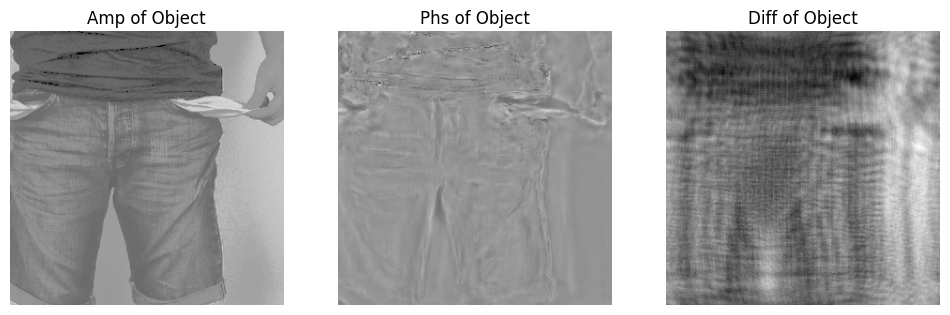

In [4]:
diff_tensor,label_tensor,tf = next(iter(dataloader_test))
# 查看数据形状
print(f"shape of label: {label_tensor.shape}")
print(f"type of label: {label_tensor.dtype}")
print(f"shape of diff: {diff_tensor.shape}")
print(f"type of diff: {diff_tensor.dtype}")

print(f'amp max:{torch.max(torch.abs(label_tensor))}')
print(f'amp min:{torch.min(torch.abs(label_tensor))}')
print(f'phs max:{torch.max(torch.angle(label_tensor))}')
print(f'phs min:{torch.min(torch.angle(label_tensor))}')

plt.figure()
fig,axes = plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(torch.abs(label_tensor).detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[0].axis('off')
axes[0].set_title('Amp of Object')
axes[1].imshow(torch.angle(label_tensor).detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[1].axis('off')
axes[1].set_title('Phs of Object')
axes[2].imshow(diff_tensor.detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[2].axis('off')
axes[2].set_title('Diff of Object')
plt.show()

### 创建模型、损失、优化器

In [5]:
pinet_cpx = PINet_cpx_v6(fold_iters=fold_iters).to(device)
print("This model has", sum(p.numel() for p in pinet_cpx.parameters()), "parameters.")
# criterion = ComplexLoss_re_im(weight_real=1.5, weight_imag=1.5, weight_diff=0)
criterion = ComplexLoss_amp_phs(weight_amp=1, weight_phs=1, weight_diff=1)
optimizer = torch.optim.Adam(pinet_cpx.parameters(),lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)

This model has 3880198 parameters.


torch.Size([1, 1, 256, 256])


<Figure size 640x480 with 0 Axes>

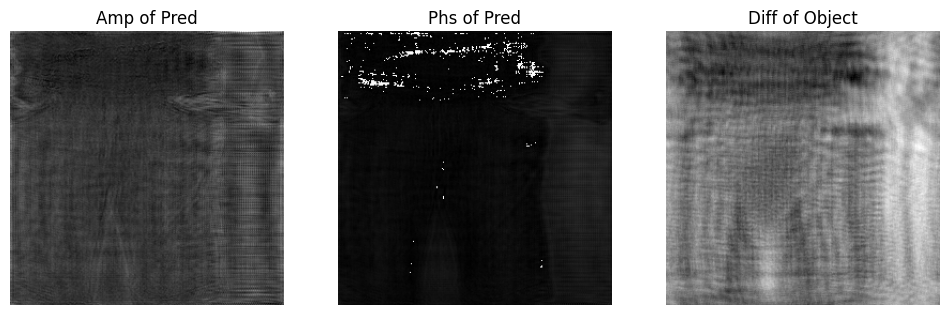

输入图像最大值: 0.9056941866874695
输入图像最小值: 0.18051795661449432
生成振幅最大值: 1.9374921321868896
生成振幅最小值: 0.4292031228542328
生成相位最大值: 3.1414496898651123
生成相位最小值: -3.141509771347046


In [6]:
# 测试模型是否能跑
print(diff_tensor.shape)
pred, y_rec = pinet_cpx(diff_tensor.to(device),TF_torch)
plt.figure()
fig,axes = plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(torch.abs(pred).detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[0].axis('off')
axes[0].set_title('Amp of Pred')
axes[1].imshow(torch.angle(pred).detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[1].axis('off')
axes[1].set_title('Phs of Pred')
axes[2].imshow(diff_tensor.detach().cpu().squeeze(0).squeeze(0),cmap='gray')
axes[2].axis('off')
axes[2].set_title('Diff of Object')
plt.show()
print(f"输入图像最大值: {diff_tensor.max()}")
print(f"输入图像最小值: {diff_tensor.min()}")
print(f"生成振幅最大值: {torch.abs(pred).max()}")
print(f"生成振幅最小值: {torch.abs(pred).min()}")
print(f"生成相位最大值: {torch.angle(pred).max()}")
print(f"生成相位最小值: {torch.angle(pred).min()}")

#### Checkpoint

In [7]:
# Checkpoint路径
model_name = 'model_pinet_size256_epoch_160_batchsize4_1.5mm_to_3mm.pth'
checkpoint_path = os.path.join(model_save_folder, model_name)

# 尝试加载checkpoint，如果存在则恢复训练
def load_checkpoint(checkpoint_path, model, optimizer, scheduler):
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        print(f"Checkpoint loaded, starting from epoch {epoch + 1}")
        return epoch, loss
    else:
        print("No checkpoint found, starting from scratch.")
        return 0, None

## 模型训练

In [8]:
from tqdm import tqdm
import logging

# 配置 logging（追加写入，不删除旧日志）
log_file_path = os.path.join(model_save_folder, log_name)
logging.basicConfig(
    filename=log_file_path,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    force=True
)

# 若有则载入模型
start_epoch, _ = load_checkpoint(checkpoint_path, pinet_cpx, optimizer, scheduler)

# 保存每个epoch的loss到一个文件
loss_file_path = os.path.join(model_save_folder, "losses.txt")
loss_file_written = False  # 用来标识文件是否已经写过表头
if os.path.exists(loss_file_path):
    os.remove(loss_file_path)  # 如果文件存在，先删除
with open(loss_file_path, "w") as f:
    f.write("Epoch Loss\n")  # 写入表头

logging.info("")
logging.info("========== New Training Session ==========")

# 训练过程
for epoch in range(start_epoch, epochs):
    running_loss = 0
    with tqdm(dataloader, desc=f"Epoch [{epoch+1}/{epochs}]", unit="batch") as progress_bar:
        for diff, obj, TF_torch in progress_bar:
            diff = diff.to(device)
            obj = obj.to(device)
            pred, y_rec = pinet_cpx(diff, TF_torch)
            loss = criterion(pred, obj, diff, y_rec)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item(), lr=scheduler.get_last_lr()[0])

    scheduler.step()
    avg_loss = running_loss / len(dataloader)
    log_message = f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}"
    print(log_message)
    logging.info(log_message)  # 将输出保存到日志文件
    with open(loss_file_path, "a") as f:  # 后续追加到文件末尾
        f.write(f"{avg_loss:.4f}\n")

    # 清理 GPU 缓存
    torch.cuda.empty_cache()

    # 每20个轮次保存一次模型
    if (epoch + 1) % 10 == 0:
        model_name = f"model_pinet_size{size}_epoch_{epoch+1}_batchsize{batch_size}_{z_low}mm_to_{z_high}mm.pth"
        model_path = os.path.join(model_save_folder, model_name)

        # 计算批次的 PSNR
        total_psnr_amp = 0
        total_psnr_phs = 0
        total_samples = 0

        with torch.no_grad():  # 禁用梯度计算以节省内存
            for diff, obj, TF_torch in dataloader_test:
                diff = diff.to(device)
                obj = obj.to(device)
                pred, y_rec = pinet_cpx(diff, TF_torch)

                # 使用模型得到预测值
                pred_amp = torch.abs(pred)
                pred_phs = torch.angle(pred)
                obj_amp = torch.abs(obj)
                obj_phs = torch.angle(obj)

                # 计算 PSNR（使用 skimage 方法）
                psnr_amp = compute_psnr_skimage_single(pred_amp, obj_amp)
                psnr_phs = compute_psnr_skimage_single(pred_phs, obj_phs)

                # 累计 PSNR 和样本数量
                total_psnr_amp += psnr_amp
                total_psnr_phs += psnr_phs
                total_samples += 1

        # 计算平均 PSNR
        avg_psnr_amp = total_psnr_amp / total_samples
        avg_psnr_phs = total_psnr_phs / total_samples
        psnr_message = f'PSNR_amp:{avg_psnr_amp:.2f}dB,PSNR_phs:{avg_psnr_phs:.2f}dB'
        print(psnr_message)
        logging.info(psnr_message)  # 保存PSNR到日志

        # 保存模型的state_dict以及其他训练状态
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': pinet_cpx.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': avg_loss,
        }, model_path)

        torch.cuda.empty_cache()
        print(f"Model saved at {model_path}")

Loading checkpoint from model_saved_pinet_compared4/model_pinet_size256_epoch_160_batchsize4_1.5mm_to_3mm.pth
Checkpoint loaded, starting from epoch 161


Epoch [161/200]: 100%|██████████| 250/250 [01:46<00:00,  2.35batch/s, loss=0.00105, lr=3.95e-6] 


Epoch [161/200], Loss: 0.0013


Epoch [162/200]: 100%|██████████| 250/250 [01:45<00:00,  2.38batch/s, loss=0.00157, lr=3.87e-6] 


Epoch [162/200], Loss: 0.0013


...

Epoch [198/200], Loss: 0.0013


Epoch [199/200]: 100%|██████████| 250/250 [01:44<00:00,  2.39batch/s, loss=0.0009, lr=1.83e-6]  


Epoch [199/200], Loss: 0.0013


Epoch [200/200]: 100%|██████████| 250/250 [01:44<00:00,  2.38batch/s, loss=0.00129, lr=1.79e-6] 


Epoch [200/200], Loss: 0.0013
PSNR_amp:30.45dB,PSNR_phs:26.02dB
Model saved at model_saved_pinet_compared4/model_pinet_size256_epoch_200_batchsize4_1.5mm_to_3mm.pth


## 

In [9]:
# from tqdm import tqdm
# import logging
# import gc  # ⭐ 新增：用于手动触发垃圾回收

# # 只在第一次 attempt、第一次 epoch、第 3 个 batch 强制造一次 NaN
# inject_nan = True   # 测试完可以改 False 或删掉

# # ================== 显存打印函数 ==================
# def show_mem(tag=""):
#     if not torch.cuda.is_available():
#         print(f"[{tag}] CUDA not available")
#         return
#     dev = torch.cuda.current_device()
#     alloc = torch.cuda.memory_allocated(dev) / 1024**2
#     reserv = torch.cuda.memory_reserved(dev) / 1024**2
#     print(f"[{tag}] allocated = {alloc:.1f} MB, reserved = {reserv:.1f} MB")

# # ================== 模型 / 优化器 / scheduler 初始化 ==================
# def build_model_optimizer_scheduler():
#     pinet_cpx = PINet_cpx_v6(fold_iters=fold_iters).to(device)
#     optimizer = torch.optim.Adam(pinet_cpx.parameters(), lr=lr)
#     scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)
#     start_epoch = 0
#     return pinet_cpx, optimizer, scheduler, start_epoch

# # ================== 日志 & 统计文件 ==================
# os.makedirs(model_save_folder, exist_ok=True)

# log_file_path = os.path.join(model_save_folder, log_name)
# if os.path.exists(log_file_path):
#     os.remove(log_file_path)

# logging.basicConfig(
#     filename=log_file_path,
#     level=logging.INFO,
#     format="%(asctime)s - %(message)s"
# )

# loss_file_path = os.path.join(model_save_folder, "losses.txt")
# if os.path.exists(loss_file_path):
#     os.remove(loss_file_path)
# with open(loss_file_path, "w") as f:
#     f.write("Epoch Loss\n")

# psnr_file_path = os.path.join(model_save_folder, "psnr.txt")
# if os.path.exists(psnr_file_path):
#     os.remove(psnr_file_path)
# with open(psnr_file_path, "w") as f:
#     f.write("PSNR\n")

# # ================== 重启相关设置 ==================
# max_restarts = 10
# restart_count = 0
# printed_mem_profile = False  # 只打印一次显存 profile

# while True:
#     print(f"\n========== Training attempt {restart_count + 1} ==========\n")
#     logging.info(f"========== Training attempt {restart_count + 1} ==========")

#     # ------- 重启前：清理上一轮模型 / 优化器 / scheduler / 损失函数 -------
#     if restart_count > 0:
#         try:
#             del pinet_cpx
#             del optimizer
#             del scheduler
#             del criterion
#         except NameError:
#             pass
#         gc.collect()
#         torch.cuda.empty_cache()

#     # ------- 初始化模型 / 优化器 / scheduler / 损失函数 -------
#     pinet_cpx, optimizer, scheduler, start_epoch = build_model_optimizer_scheduler()
#     criterion = ComplexLoss_amp_phs(weight_amp=1, weight_phs=1, weight_diff=1)

#     if not printed_mem_profile:
#         show_mem("after model init")

#     nan_flag = False  # 当前 attempt 是否因 NaN 中断

#     # ================== 训练循环 ==================
#     for epoch in range(start_epoch, epochs):
#         running_loss = 0.0

#         with tqdm(dataloader, desc=f"Epoch [{epoch+1}/{epochs}]", unit="batch") as progress_bar:
#             for batch_idx, (diff, obj) in enumerate(progress_bar):

#                 # 第一次 batch 的显存 profile
#                 if not printed_mem_profile:
#                     show_mem("before move first batch to GPU")

#                 diff = diff.to(device)
#                 obj = obj.to(device)

#                 if not printed_mem_profile:
#                     show_mem("after move first batch to GPU")

#                 pred, y_rec = pinet_cpx(diff, TF_torch)

#                 if not printed_mem_profile:
#                     show_mem("after first forward")

#                 loss = criterion(pred, obj, diff, y_rec)

#                 # ====== 手动造 NaN（只在第一次 attempt 的 epoch0 的第 3 个 batch） ======
#                 if inject_nan and restart_count == 0 and epoch == 0 and batch_idx == 2:
#                     print(">>> Debug: 强制将 loss 置为 NaN，用于测试重启逻辑")
#                     loss = loss * float('nan')
#                 # ===================================================================

#                 optimizer.zero_grad()
#                 loss.backward()

#                 if not printed_mem_profile:
#                     show_mem("after first backward")

#                 # ------- backward 之后检查 NaN / Inf -------
#                 if not torch.isfinite(loss):
#                     msg = (f"[NaN DETECTED] Epoch {epoch+1}, batch {batch_idx}, "
#                            f"loss = {loss.item()}，重启训练。")
#                     print(msg)
#                     logging.warning(msg)
#                     nan_flag = True

#                     # 当前 batch 的大 tensor 手动释放引用
#                     del diff, obj, pred, y_rec, loss
#                     gc.collect()
#                     torch.cuda.empty_cache()
#                     break  # 跳出 batch 循环，结束本 attempt

#                 optimizer.step()

#                 if not printed_mem_profile:
#                     show_mem("after first optimizer.step()")
#                     printed_mem_profile = True  # 后面不再打印

#                 running_loss += loss.item()
#                 progress_bar.set_postfix(loss=loss.item(), lr=scheduler.get_last_lr()[0])

#                 # 用完的变量也可以顺手删（不是必须，想更抠显存可以留着）
#                 del diff, obj, pred, y_rec, loss
#                 gc.collect()
#                 torch.cuda.empty_cache()

#         # 如果这一轮因为 NaN 退出
#         if nan_flag:
#             torch.cuda.empty_cache()
#             break

#         # ------- 正常收尾一个 epoch -------
#         scheduler.step()
#         avg_loss = running_loss / len(dataloader)
#         log_message = f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}"
#         print(log_message)
#         logging.info(log_message)

#         with open(loss_file_path, "a") as f:
#             f.write(f"{avg_loss:.4f}\n")

#         torch.cuda.empty_cache()

#         # ================== 每 10 个 epoch 评估 + 保存模型 ==================
#         if (epoch + 1) % 10 == 0:
#             model_name = f"model_pinet_size{size}_epoch_{epoch+1}_batchsize{batch_size}.pth"
#             model_path = os.path.join(model_save_folder, model_name)

#             total_psnr_amp = 0.0
#             total_psnr_phs = 0.0
#             total_samples = 0

#             with torch.no_grad():
#                 for diff, obj in dataloader_test:
#                     diff = diff.to(device)
#                     obj = obj.to(device)
#                     pred, y_rec = pinet_cpx(diff, TF_torch)

#                     pred_amp = torch.abs(pred)
#                     pred_phs = torch.angle(pred)
#                     obj_amp = torch.abs(obj)
#                     obj_phs = torch.angle(obj)

#                     psnr_amp = compute_psnr_skimage_single(pred_amp, obj_amp)
#                     psnr_phs = compute_psnr_skimage_single(pred_phs, obj_phs)

#                     total_psnr_amp += psnr_amp
#                     total_psnr_phs += psnr_phs
#                     total_samples += 1

#                     # 评估阶段也顺手释放
#                     del diff, obj, pred, y_rec, pred_amp, pred_phs, obj_amp, obj_phs
#                     gc.collect()
#                     torch.cuda.empty_cache()

#             avg_psnr_amp = total_psnr_amp / total_samples
#             avg_psnr_phs = total_psnr_phs / total_samples
#             psnr_message = f'PSNR_amp:{avg_psnr_amp:.2f}dB,PSNR_phs:{avg_psnr_phs:.2f}dB'
#             print(psnr_message)
#             logging.info(psnr_message)

#             with open(psnr_file_path, "a") as f:
#                 f.write(f'PSNR_amp:{avg_psnr_amp}dB,PSNR_phs:{avg_psnr_phs}dB\n')

#             torch.save({
#                 'epoch': epoch + 1,
#                 'model_state_dict': pinet_cpx.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'scheduler_state_dict': scheduler.state_dict(),
#                 'loss': avg_loss,
#             }, model_path)
#             torch.cuda.empty_cache()
#             print(f"Model saved at {model_path}")

#     # ================== attempt 结束后：判断是否重启 ==================
#     if nan_flag:
#         restart_count += 1
#         if restart_count >= max_restarts:
#             print(f"训练多次出现 NaN，已重启 {max_restarts} 次，停止。")
#             logging.error(f"训练多次出现 NaN，已重启 {max_restarts} 次，停止。")
#             break
#         else:
#             print("NaN 出现，重新从头开始训练一次。")
#             logging.warning("NaN 出现，重新从头开始训练一次。")
#             continue  # 回到 while True，重新初始化模型开始下一次 attempt
#     else:
#         print("训练完成（未出现 NaN）。")
#         logging.info("训练完成（未出现 NaN）。")
#         break

In [10]:
print(torch.cuda.memory_allocated(0) / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved(0) / 1024**2, "MB reserved")
# del pinet_cpx
# gc.collect()
# torch.cuda.empty_cache()

68.4951171875 MB allocated
394.0 MB reserved


## 